# IBL Brain-Wide Map Project

Analysis notebook built on the International Brain Laboratory (IBL) Brain-Wide Map dataset.

The dataset contains whole-mouse-brain Neuropixels recordings during a standardized visual decision-making task. This notebook sets up the connection to the public IBL data server, downloads precomputed PSTHs, and defines utility functions for loading and analyzing neural activity.

## Running this notebook

**Google Colab:** Just run all cells. The first cell auto-installs any missing dependencies.

**Locally:** Create an environment and install dependencies first:

```bash
python -m venv .venv
# Windows:  .venv\Scripts\activate
# macOS/Linux:  source .venv/bin/activate
pip install -r requirements.txt
```

Then select the `.venv` as your notebook kernel and run all cells. The setup cell will report any packages still missing.

## Install dependencies, setup, and import libraries

In [ ]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running in Colab")
    %pip install -q ONE-api ibllib ibl-style
else:
    print("Running locally — install deps with: pip install -r requirements.txt")

Running in Colab
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.6/442.6 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.1/226.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# When running in jupyter set number of threads to 1
from one.api import ONE
import os
os.environ.setdefault('ONE_HTTP_DL_THREADS', '1')

ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


### **Define imports**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd
from scipy import sparse
import numpy as np
from one.remote.aws import s3_download_file
import zipfile
import tqdm
import scipy.stats as stats
from iblutil.util import Bunch
from scipy.ndimage import gaussian_filter1d

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# This is to view dataframe interactively in Google colab
if 'google.colab' in sys.modules:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()

# This is to style figures (optional — skip gracefully if unavailable)
try:
    from ibl_style.style import figure_style
    figure_style()
except Exception as e:
    print(f"ibl_style not applied ({e}); using default matplotlib style")

## Data Access

### Data Format

This project uses **precomputed PSTHs** (peri-stimulus time histograms) for all *good* clusters in the Brain-Wide Map. The data is provided as three ZIP archives, one per task-event alignment:

| Event | File | Aligned to |
| --- | --- | --- |
| `stimOn` | `data_stimOn.zip` | Stimulus onset |
| `firstMove` | `data_firstMove.zip` | First wheel movement |
| `feedback` | `data_feedback.zip` | Reward / error feedback |

Each archive (~810 MB) contains:

- **`clusters.pqt`** — per-cluster metadata. Key columns: `psth_index` (row into the PSTH array), `uuids` (globally unique cluster id), `cluster_id`, `firing_rate`, `x`/`y`/`z` (CCF coordinates), `atlas_id_allen`, `pid` (probe insertion), `acronym` (Allen CCF brain region), `acronym_allen`.
- **`trials.pqt`** — trial variables: `contrastLeft`, `contrastRight`, `choice`, `probabilityLeft` (block), `feedback`.
- **`sessions.pqt`** — session info mapping `eid` ↔ `pid`, plus `subject`, `lab`.
- **`t.npy`** — PSTH timebase, from −0.5 s to +1.0 s in 10 ms bins (150 bins, `dt = 0.01`).
- **`{pid}.npz`** — one sparse PSTH array per probe insertion, reshaped to `(trials, clusters, nbins)`.

**IDs:** an `eid` identifies an *experimental session*; a `pid` identifies a single *probe insertion*. One session (`eid`) can have multiple probe insertions (`pid`s).

### Data downloading and loading utilities

The functions below download, unzip, and load the data into memory. `download_data(event)` fetches and extracts an archive; `load_metadata(event)` reads the metadata tables and PSTH timebase into a `Bunch`; `load_psth(...)` loads a probe insertion's sparse PSTH; and the `get_*_psth_*` helpers aggregate PSTHs by probe insertion, brain region, or specific clusters (optionally split by a task variable).

In [ ]:
def download_data(event):
  assert event in ['firstMove', 'stimOn', 'feedback'], 'event must be one of "firstMove", "stimOn" or "feedback'

  # Dataset name
  fname = f'data_{event}.zip'
  # Remote location of data
  s3_data_path = f'sample_data/Neuromatch/{fname}'
  # Local location to download data to
  save_path = one.cache_dir.joinpath('Neuromatch', fname)
  save_path.parent.mkdir(exist_ok=True, parents=True)

  # Download file
  file = s3_download_file(s3_data_path, save_path)
  # Unzip content
  with zipfile.ZipFile(file, 'r') as zip_ref:
    zip_ref.extractall(save_path.parent)


def get_data_path(event):

  return one.cache_dir.joinpath('Neuromatch', f'data_{event}')

### **Define loading utility functions** <a name="Utility-functions"></a>

In [ ]:
def load_metadata(event):
  metadata = Bunch()
  data_path = get_data_path(event)
  metadata['clusters'] = pd.read_parquet(data_path.joinpath('clusters.pqt'))
  metadata['trials'] = pd.read_parquet(data_path.joinpath('trials.pqt'))
  metadata['sessions'] = pd.read_parquet(data_path.joinpath('sessions.pqt'))
  metadata['times'] = np.load(data_path.joinpath('t.npy'))
  metadata['nbins'] = metadata['times'].size
  metadata['dt'] = np.round(np.median(np.diff(metadata['times'])), 2)
  metadata['data_path'] = data_path

  return metadata


def load_times(data_path):
  return np.load(data_path.joinpath('t.npy'))


def load_psth(data_path, pid, nbins=150):
    psth = sparse.load_npz(data_path.joinpath(f'{pid}.npz')).toarray()
    psth = psth.reshape(psth.shape[0], -1, nbins)
    return psth

### **Define processing utility functions** <a name="Utility-functions"></a>

In [ ]:
def split_trials_by_variable(trials, split='contrast'):
  trials = trials.set_index('psth_index')
  if split == 'contrast':
    trials['contrast'] = np.nansum([trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('contrast')
  elif split == 'signed contrast':
    trials['signedContrast'] = np.nansum([-1 * trials['contrastLeft'], trials['contrastRight']], axis=0) * 100
    grp = trials.groupby('signedContrast')
  elif split == 'stimulus':
    trials['stimulus'] = 'right'
    trials.loc[trials['contrastRight'].isna(), 'stimulus'] = 'left'
    grp = trials.groupby('stimulus')
  elif split == 'choice':
    grp = trials.groupby('choice')
  elif split == 'block':
    grp = trials.groupby('probabilityLeft')
  else:
    raise NotImplementedError('split must be one of "contrast", "signed contrast", "stimulus", "choice" or "block"')

  return grp.groups


def get_avg_psth_for_insertion(pid, meta, reg=None, uuids=None, split=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)

  if split is None:
    psth = sp.mean(axis=0) / meta['dt']
  else:
    psth = dict()
    eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
    trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
    grps = split_trials_by_variable(trials, split=split)

    for key, vals in grps.items():
      psth[key] = sp[vals, :, :].mean(axis=0)

  return psth, df

def get_avg_psth_for_region(reg, meta, split=None):
  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, reg=reg, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}


  return all_psth, all_df


def get_avg_psth_for_clusters(uuids, meta, split=None):
  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_df = []
  all_psth = []
  for pid in pids:
    psth, df = get_avg_psth_for_insertion(pid, meta, uuids=uuids, split=split)
    all_df.append(df)
    all_psth.append(psth)

  all_df = pd.concat(all_df).reset_index(drop=True)
  if split is None:
    all_psth = np.concatenate(all_psth)
  else:
    all_psth = {key: np.concatenate([d[key] for d in all_psth if key in d.keys()])
    for key in all_psth[0]}

  return all_psth, all_df



def get_psth_for_insertion(pid, meta, reg=None, uuids=None):

  df = meta.clusters[meta.clusters['pid'] == pid]
  df = df[['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index']]
  sp = load_psth(meta.data_path, pid, nbins=meta.nbins)

  if reg is not None:
    in_reg = df['acronym'] == reg
    sp = sp[:, in_reg.values, :]
    df = df[in_reg].reset_index(drop=True)

  if uuids is not None:
    in_uuid = df['uuids'].isin(uuids)
    sp = sp[:, in_uuid.values, :]
    df = df[in_uuid].reset_index(drop=True)


  eid = meta.sessions[meta.sessions['pid'] == pid].iloc[0]['eid']
  trials = meta.trials[meta.trials['eid'] == eid].reset_index(drop=True)
  psth = sp / meta['dt']

  return psth, df, trials


def get_psth_for_region(reg, meta):

  clusters = meta.clusters[meta.clusters['acronym'] == reg]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, reg=reg)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials


def get_psth_for_clusters(uuids, meta):

  clusters = meta.clusters[meta.clusters['uuids'].isin(uuids)]
  pids = clusters['pid'].unique()
  all_clust = []
  all_psth = []
  all_trials = []
  for pid in pids:
    psth, clust, trials = get_psth_for_insertion(pid, meta, uuids=uuids)
    all_clust.append(clust)
    all_psth.append(psth)
    all_trials.append(trials)

  return all_psth, all_clust, all_trials

### Explore the data

Pick an event alignment, download the data, and inspect the metadata tables. Change `event` to `'firstMove'` or `'feedback'` to align to a different task event.

In [ ]:
event = 'stimOn'
download_data(event)
meta = load_metadata(event)

print('metadata keys:', list(meta.keys()))
print('n clusters:', len(meta.clusters))
print('n bins:', meta.nbins, '| dt:', meta.dt, 's')
print('time range:', meta.times[0], 'to', meta.times[-1], 's')

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_stimOn.zip: 100%|██████████| 810M/810M [00:06<00:00, 118MB/s] 


metadata keys: ['clusters', 'trials', 'sessions', 'times', 'nbins', 'dt', 'data_path']
n clusters: 75708
n bins: 150 | dt: 0.01 s
time range: -0.495 to 0.995 s


**Clusters** — each row is a single neuron. The `acronym` column gives the Allen CCF brain region; `pid` is the probe insertion; `psth_index` maps the cluster to its row in the PSTH arrays; `cluster_id` and `uuids` identify the neuron.

In [ ]:
meta.clusters

,psth_index,uuids,cluster_id,firing_rate,x,y,z,atlas_id_allen,pid,acronym,acronym_allen
0,0,c7d051dc-1358-422d-9eab-ca13c6b6be1b,2,2.831652,-0.002289,-0.002537,-0.003595,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
1,1,38bc27f2-7301-405a-a870-54e0a7b06a26,15,6.941674,-0.002289,-0.002533,-0.003576,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
2,2,1c4e5e11-ca9d-441a-bb8f-4b56dcc95054,22,2.702620,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
3,3,b48a90ed-84f4-424d-87ae-92c22a423777,23,5.210307,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
4,4,38a812b9-b374-46f8-ab14-3dd146411fc8,26,10.565215,-0.002289,-0.002528,-0.003556,549,56f2a378-78d2-4132-b3c8-8c1ba82be598,root,TH
...,...,...,...,...,...,...,...,...,...,...,...
75703,101,1ed6f713-96c5-4d33-a97f-45ad7f436ca7,950,9.926329,-0.001189,-0.000700,-0.003936,629,79f44ba1-c931-4346-82eb-f628a9374045,VAL,VAL
75704,102,1d7d0f85-2662-4844-99e2-173207669d41,951,13.529734,-0.001189,-0.000700,-0.003936,629,79f44ba1-c931-4346-82eb-f628a9374045,VAL,VAL
75705,103,7e5690d8-47d5-4e30-9c86-a3026c761900,961,7.518199,-0.001268,-0.000662,-0.003596,255,79f44ba1-c931-4346-82eb-f628a9374045,AV,AV
75706,104,94c77f09-d88c-4188-bcbb-7b6e26b26905,972,0.808297,-0.001866,-0.000671,-0.001482,478,79f44ba1-c931-4346-82eb-f628a9374045,SSp-ll,SSp-ll6a


**Available brain regions** — use these `acronym` values with `get_avg_psth_for_region(reg, meta, ...)`. The counts show how many good clusters were recorded in each region.

In [ ]:
meta.clusters['acronym'].value_counts()

,count
acronym,
root,10179
CP,2892
MRN,2678
PO,2329
LP,1812
...,...
DMX,2
IO,2
RO,1


**Trials** — task variables per trial: stimulus contrast on each side (`contrastLeft`/`contrastRight`), the animal's `choice`, the block prior (`probabilityLeft`), and the `feedback` (reward/error).

In [ ]:
meta.trials

,eid,probabilityLeft,feedbackType,contrastLeft,contrastRight,choice,psth_index,block,block_trial_number
0,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.125,NaN,1.0,0,0,9
1,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,1,0,12
2,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.250,1.0,2,0,14
3,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,1.0,0.250,NaN,1.0,3,0,16
4,6713a4a7-faed-4df2-acab-ee4e63326f8d,0.5,-1.0,NaN,0.125,1.0,4,0,19
...,...,...,...,...,...,...,...,...,...
196498,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,0.2,1.0,NaN,0.125,-1.0,1084,23,11
196499,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,0.2,1.0,NaN,0.125,-1.0,1085,23,14
196500,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,0.2,-1.0,NaN,0.000,1.0,1086,23,17
196501,c7bd79c9-c47e-4ea5-aea3-74dda991b48e,0.2,1.0,NaN,0.000,-1.0,1087,23,18


## Analysis

This is your scaffold — build your own project below. The utilities above give you PSTHs aligned to `stimOn`, `firstMove`, or `feedback`, filterable by brain region or cluster, and splittable by task variable.

**Example: average PSTH for a brain region, split by a task variable**

```python
reg = 'VISp'  # pick a region from meta.clusters['acronym'].value_counts()
psth, df = get_avg_psth_for_region(reg, meta, split='choice')

for key, arr in psth.items():
    plt.plot(meta.times, arr.mean(axis=0), label=f'{key}')
plt.axvline(0, color='k', ls='--', lw=1)
plt.xlabel(f'Time from {event} (s)')
plt.ylabel('Firing rate (sp/s)')
plt.legend(title='choice')
plt.show()
```

**Ideas to explore:**

- Compare neural responses across brain regions or task events
- Split PSTHs by `contrast`, `signed contrast`, `stimulus`, `choice`, or `block`
- Run PCA on population activity (`PCA` is imported)
- Decode stimulus or choice from population activity (`LogisticRegression` + `train_test_split` are imported)
- Smooth PSTHs with `gaussian_filter1d` for cleaner traces

## RQ1

In [ ]:
from scipy.stats import wilcoxon
import statsmodels.stats.multitest as smm

In [ ]:
download_data('stimOn')
meta = load_metadata('stimOn')

In [ ]:
pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"

In [ ]:
psth, df, trials = get_psth_for_insertion(pid, meta)

In [ ]:
pre_window_idx = (meta['times'] >= -0.2) & (meta['times'] < 0.0)
post_window_idx = (meta['times'] >= 0.0) & (meta['times'] <= 0.2)

n_trials, n_clusters, _ = psth.shape
p_values = []
modulation_indices = []

for c in range(n_clusters):
    trial_pre_rates = np.mean(psth[:, c, pre_window_idx], axis=1)
    trial_post_rates = np.mean(psth[:, c, post_window_idx], axis=1)

    mean_pre = np.mean(trial_pre_rates)
    mean_post = np.mean(trial_post_rates)

    if (mean_pre + mean_post) == 0:
        mi = 0.0
    else:
        mi = abs(mean_post - mean_pre) / (mean_post + mean_pre)
    modulation_indices.append(mi)

    if np.array_equal(trial_pre_rates, trial_post_rates):
        p_values.append(1.0)
    else:
        stat, p_val = wilcoxon(trial_post_rates, trial_pre_rates)
        p_values.append(p_val)

df['p_value'] = p_values
df['modulation_index'] = modulation_indices

In [ ]:
reject, pvals_corrected, _, _ = smm.multipletests(df['p_value'].values, alpha=0.05, method='fdr_bh')
df['is_responsive'] = reject

In [ ]:
region_stats = df.groupby('acronym').agg(
    total_units=('cluster_id', 'count'),
    responsive_units=('is_responsive', 'sum')
).reset_index()

region_stats['percent_responsive'] = (region_stats['responsive_units'] / region_stats['total_units']) * 100

region_stats = region_stats.sort_values(by='percent_responsive', ascending=False)

print("\n--- Regional Responsiveness Leaderboard ---")
print(region_stats[['acronym', 'total_units', 'responsive_units', 'percent_responsive']].to_string(index=False))


--- Regional Responsiveness Leaderboard ---
acronym  total_units  responsive_units  percent_responsive
    MRN            6                 6          100.000000
    CA1           13                 9           69.230769
  VISam           17                11           64.705882
    APN           30                19           63.333333
   root            8                 5           62.500000
     DG            5                 3           60.000000
  VISpm           43                25           58.139535


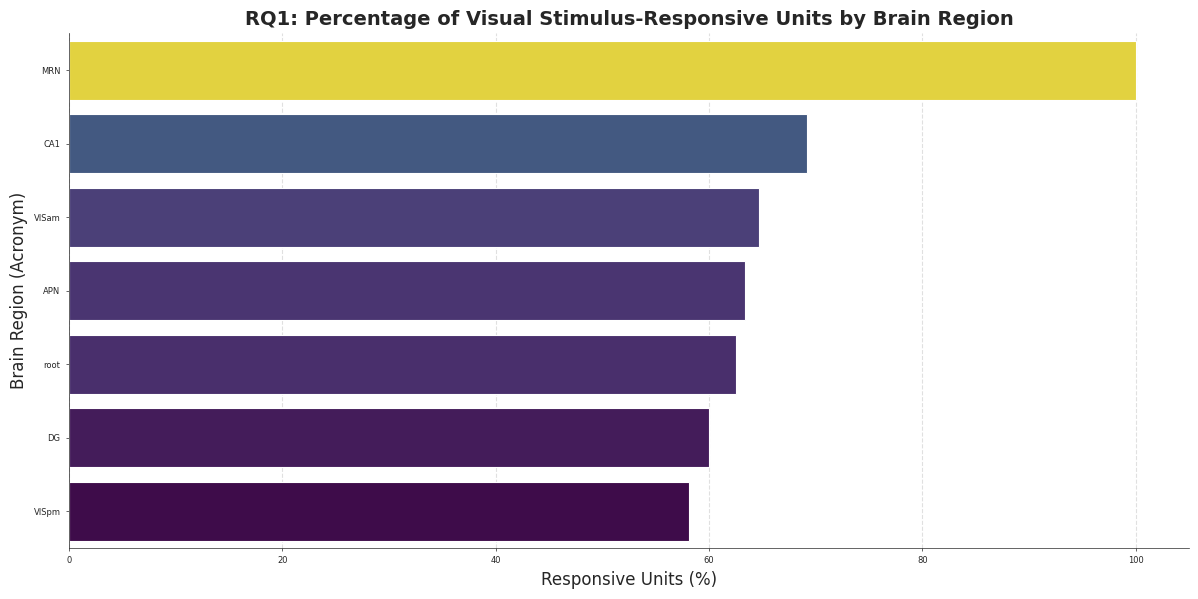

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=region_stats,
    x='percent_responsive',
    y='acronym',
    palette='viridis',
    hue='percent_responsive',
    legend=False
)

plt.title('RQ1: Percentage of Visual Stimulus-Responsive Units by Brain Region', fontsize=14, fontweight='bold')
plt.xlabel('Responsive Units (%)', fontsize=12)
plt.ylabel('Brain Region (Acronym)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Found 698 unique probe insertions across the dataset. Processing neural records...


Processing Sessions: 100%|██████████| 698/698 [01:53<00:00,  6.13it/s]
/tmp/ipykernel_1006/3140367199.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(



Successfully gathered metrics for 75708 total neurons across all sessions.

--- Unified Cross-Session Brain-Wide Visual Responsiveness Leaderboard (Top 15) ---
acronym  total_units  responsive_units  avg_modulation_index  percent_responsive
    CLI           89                74              0.212654           83.146067
     FN           46                38              0.146619           82.608696
    NPC           71                58              0.132787           81.690141
   PGRN          120                98              0.277568           81.666667
    RPF           42                34              0.231675           80.952381
     DN          197               155              0.176639           78.680203
     I5           42                33              0.215898           78.571429
    GRN          560               438              0.327466           78.214286
   MARN           83                64              0.387026           77.108434
    LDT           51         

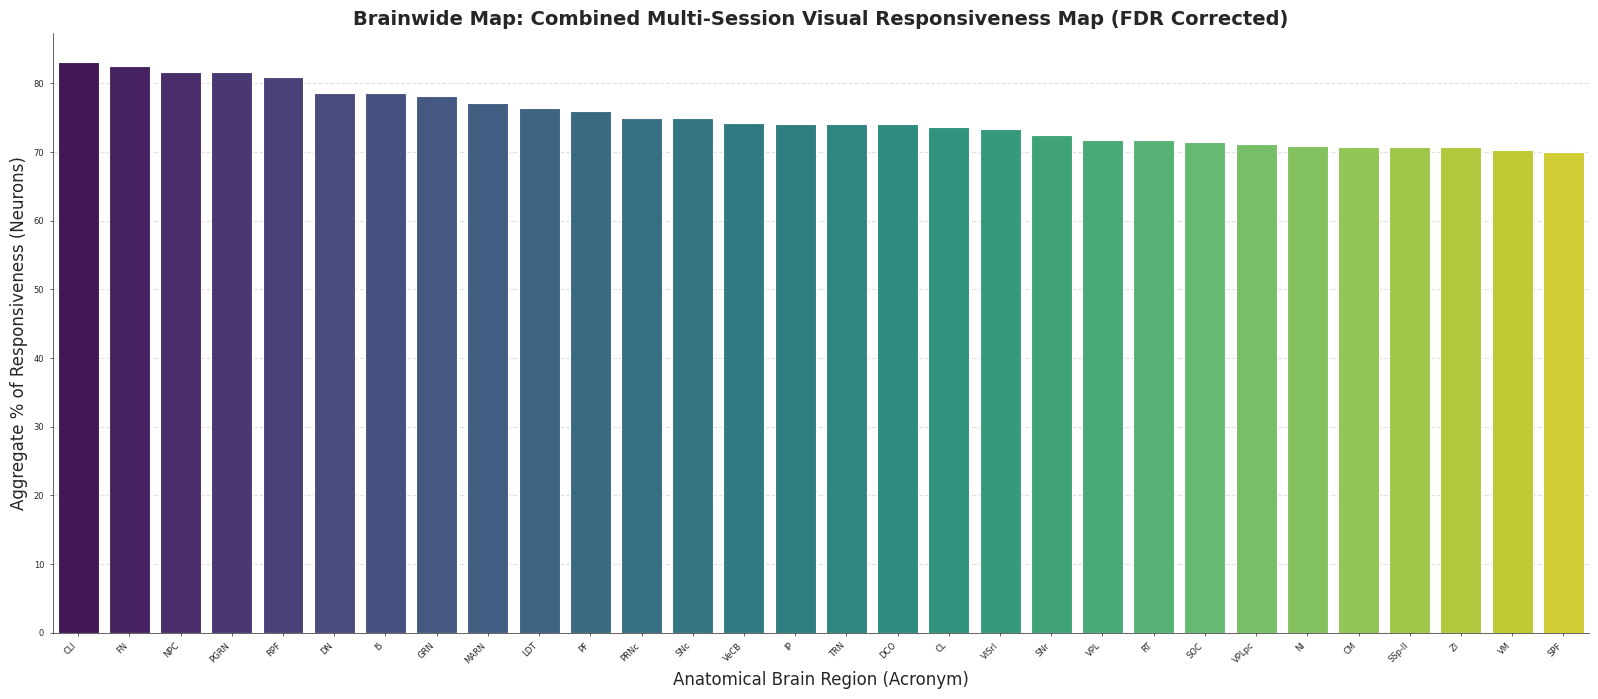

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.stats.multitest as smm
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

download_data('stimOn')
meta = load_metadata('stimOn')

pre_window_idx = (meta['times'] >= -0.2) & (meta['times'] < 0.0)
post_window_idx = (meta['times'] >= 0.0) & (meta['times'] <= 0.2)

all_pids = meta.clusters['pid'].unique()
print(f"Found {len(all_pids)} unique probe insertions across the dataset. Processing neural records...")

global_neuron_records = []

for pid in tqdm(all_pids, desc="Processing Sessions"):
    try:
        pid_clusters = meta.clusters[meta.clusters['pid'] == pid]
        if pid_clusters.empty:
            continue

        sp = load_psth(meta.data_path, pid, nbins=meta.nbins)
        psth = sp / meta['dt'] # Convert to spikes/sec firing rate

        n_trials, n_clusters_in_psth, n_time_bins = psth.shape

        for _, row in pid_clusters.iterrows():
            psth_idx = row['psth_index']
            region = row['acronym']
            cluster_uuid = row['uuids']

            trial_pre_rates = np.mean(psth[:, psth_idx, pre_window_idx], axis=1)
            trial_post_rates = np.mean(psth[:, psth_idx, post_window_idx], axis=1)

            mean_pre = np.mean(trial_pre_rates)
            mean_post = np.mean(trial_post_rates)

            if (mean_post + mean_pre) == 0:
                mi = 0.0
            else:
                mi = abs(mean_post - mean_pre) / (mean_post + mean_pre)

            if np.all(trial_post_rates == trial_pre_rates):
                p_val = 1.0
            else:
                stat, p_val = wilcoxon(trial_post_rates, trial_pre_rates)

            global_neuron_records.append({
                'uuid': cluster_uuid,
                'pid': pid,
                'acronym': region,
                'mean_pre': mean_pre,
                'mean_post': mean_post,
                'modulation_index': mi,
                'p_value': p_val
            })

    except Exception as e:
        continue

global_df = pd.DataFrame(global_neuron_records)
print(f"\nSuccessfully gathered metrics for {len(global_df)} total neurons across all sessions.")

global_df['p_value'] = global_df['p_value'].fillna(1.0)

reject, pvals_corrected, _, _ = smm.multipletests(
    global_df['p_value'].values,
    alpha=0.05,
    method='fdr_bh'
)
global_df['is_responsive'] = reject

region_leaderboard = global_df.groupby('acronym').agg(
    total_units=('uuid', 'count'),
    responsive_units=('is_responsive', 'sum'),
    avg_modulation_index=('modulation_index', 'mean')
).reset_index()

region_leaderboard['percent_responsive'] = (region_leaderboard['responsive_units'] / region_leaderboard['total_units']) * 100

region_leaderboard = region_leaderboard[region_leaderboard['total_units'] >= 20]

region_leaderboard = region_leaderboard.sort_values(by='percent_responsive', ascending=False)

print("\n--- Unified Cross-Session Brain-Wide Visual Responsiveness Leaderboard (Top 15) ---")
print(region_leaderboard.head(15).to_string(index=False))

plt.figure(figsize=(16, 7))
sns.barplot(
    data=region_leaderboard.head(30),
    x='acronym',
    y='percent_responsive',
    palette='viridis'
)

plt.title('Brainwide Map: Combined Multi-Session Visual Responsiveness Map (FDR Corrected)', fontsize=14, fontweight='bold')
plt.xlabel('Anatomical Brain Region (Acronym)', fontsize=12)
plt.ylabel('Aggregate % of Responsiveness (Neurons)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## RQ2

In [ ]:
responsive_df = df[df['is_responsive'] == True].copy()
responsive_indices = responsive_df.index.values

print(f"Analyzing latency for {len(responsive_indices)} responsive units...")

times = meta['times']
bin_size_ms = (times[1] - times[0]) * 1000

pre_window_idx = (times >= -0.2) & (times < 0.0)

stim_on_bin_idx = np.where(times >= 0.0)[0][0]

latencies_ms = []

Analyzing latency for 78 responsive units...


In [ ]:
for df_original_idx in responsive_indices:
    psth_array_idx = responsive_df.loc[df_original_idx, 'psth_index']

    single_psth = psth[:, psth_array_idx, :].mean(axis=0)

    baseline_vals = single_psth[pre_window_idx]
    baseline_mean = np.mean(baseline_vals)
    baseline_std = np.std(baseline_vals)

    if baseline_std == 0:
        baseline_std = 1e-6

    latency_found = False
    post_scan_bins = np.where((times >= 0.0) & (times <= 0.3))[0]

    for bin_idx in post_scan_bins:
        current_firing_rate = single_psth[bin_idx]

        if abs(current_firing_rate - baseline_mean) > (2 * baseline_std):
            time_at_bin = times[bin_idx]
            latency_in_ms = time_at_bin * 1000

            latencies_ms.append(latency_in_ms)
            latency_found = True
            break

    if not latency_found:
        latencies_ms.append(np.nan)

responsive_df['latency_ms'] = latencies_ms

responsive_df = responsive_df.dropna(subset=['latency_ms'])

In [ ]:
region_latencies = responsive_df.groupby('acronym')['latency_ms'].median().reset_index()
region_latencies = region_latencies.sort_values(by='latency_ms')

ordered_regions = region_latencies['acronym'].values

print("\n--- Chronological Regional Latency (Medians) ---")
print(region_latencies.to_string(index=False))


--- Chronological Regional Latency (Medians) ---
acronym  latency_ms
    APN        45.0
    CA1        45.0
   root        45.0
  VISam        65.0
  VISpm        65.0
    MRN        70.0
     DG       145.0


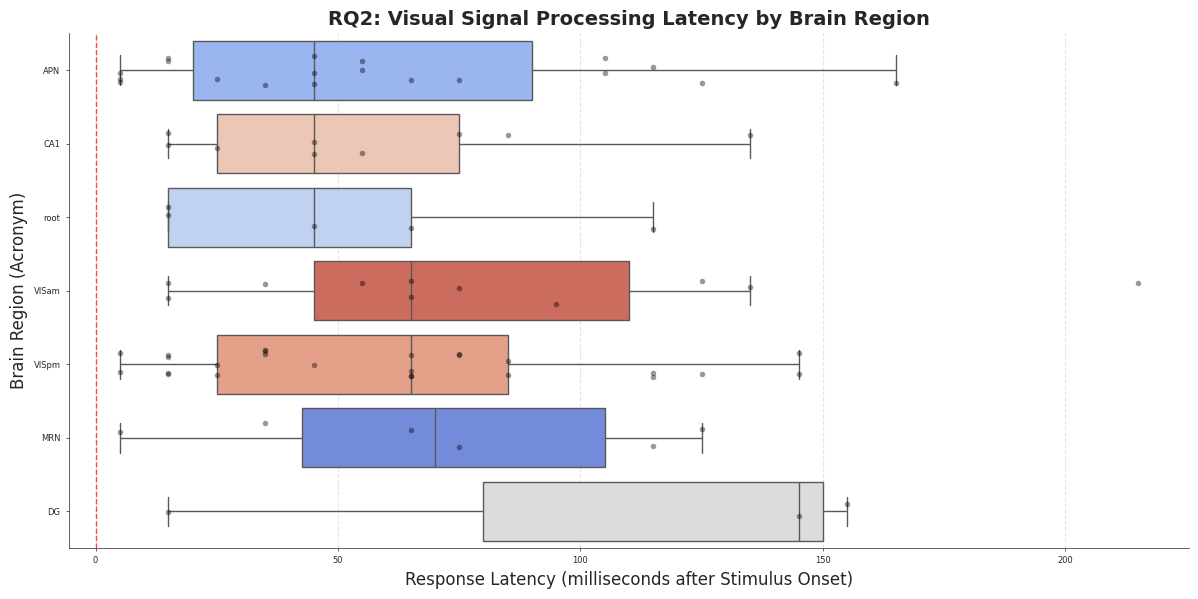

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=responsive_df,
    x='latency_ms',
    y='acronym',
    order=ordered_regions,
    palette='coolwarm',
    hue='acronym',
    legend=False,
    fliersize=0
)

sns.stripplot(
    data=responsive_df,
    x='latency_ms',
    y='acronym',
    order=ordered_regions,
    color='black',
    alpha=0.4,
    size=4,
    jitter=0.2
)

plt.title('RQ2: Visual Signal Processing Latency by Brain Region', fontsize=14, fontweight='bold')
plt.xlabel('Response Latency (milliseconds after Stimulus Onset)', fontsize=12)
plt.ylabel('Brain Region (Acronym)', fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Stimulus Onset (0ms)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## RQ3

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [ ]:
download_data('firstMove')
meta_mv = load_metadata('firstMove')

pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"
psth_mv, df_mv, trials_mv = get_psth_for_insertion(pid, meta_mv)

choices = trials_mv['choice'].values
valid_idx = (choices == 1) | (choices == -1)

X_all_neurons = psth_mv[valid_idx, :, :]
y = np.where(choices[valid_idx] == 1, 1, 0)

(S3) /root/Downloads/ONE/openalyx.internationalbrainlab.org/Neuromatch/data_firstMove.zip: 100%|██████████| 823M/823M [00:11<00:00, 71.9MB/s]


In [ ]:
mv_times = meta_mv['times']
pre_move_idx = (mv_times >= -0.15) & (mv_times <= 0.0)

X_pre_move = np.mean(X_all_neurons[:, :, pre_move_idx], axis=2)

In [ ]:
unique_regions = df_mv['acronym'].unique()
decoding_results = []

MIN_NEURONS = 5

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for region in unique_regions:
    region_neuron_indices = np.where(df_mv['acronym'].values == region)[0]

    if len(region_neuron_indices) < MIN_NEURONS:
        continue

    X_region = X_pre_move[:, region_neuron_indices]

    true_accuracies = []
    shuffled_accuracies = []

    y_shuffled = np.random.permutation(y)

    for train_idx, test_idx in cv.split(X_region, y):
        X_train, X_test = X_region[train_idx], X_region[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        y_train_shuff, y_test_shuff = y_shuffled[train_idx], y_shuffled[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = LogisticRegression(C=1.0, max_iter=1000, solver='liblinear')

        model.fit(X_train_scaled, y_train)
        true_accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

        model.fit(X_train_scaled, y_train_shuff)
        shuffled_accuracies.append(accuracy_score(y_test_shuff, model.predict(X_test_scaled)))

    decoding_results.append({
        'Region': region,
        'Neurons Count': len(region_neuron_indices),
        'True Accuracy': np.mean(true_accuracies),
        'Shuffle Accuracy': np.mean(shuffled_accuracies)
    })

results_df = pd.DataFrame(decoding_results)
results_df = results_df.sort_values(by='True Accuracy', ascending=False)

print("\n--- Choice Decoding Leaderboard ---")
print(results_df.to_string(index=False))


--- Choice Decoding Leaderboard ---
Region  Neurons Count  True Accuracy  Shuffle Accuracy
   APN             30       0.803483          0.485858
 VISpm             43       0.775409          0.531393
 VISam             17       0.712997          0.492309
  root              8       0.613488          0.524825
   MRN              6       0.589598          0.496657
    DG              5       0.540042          0.431884
   CA1             13       0.535507          0.485788


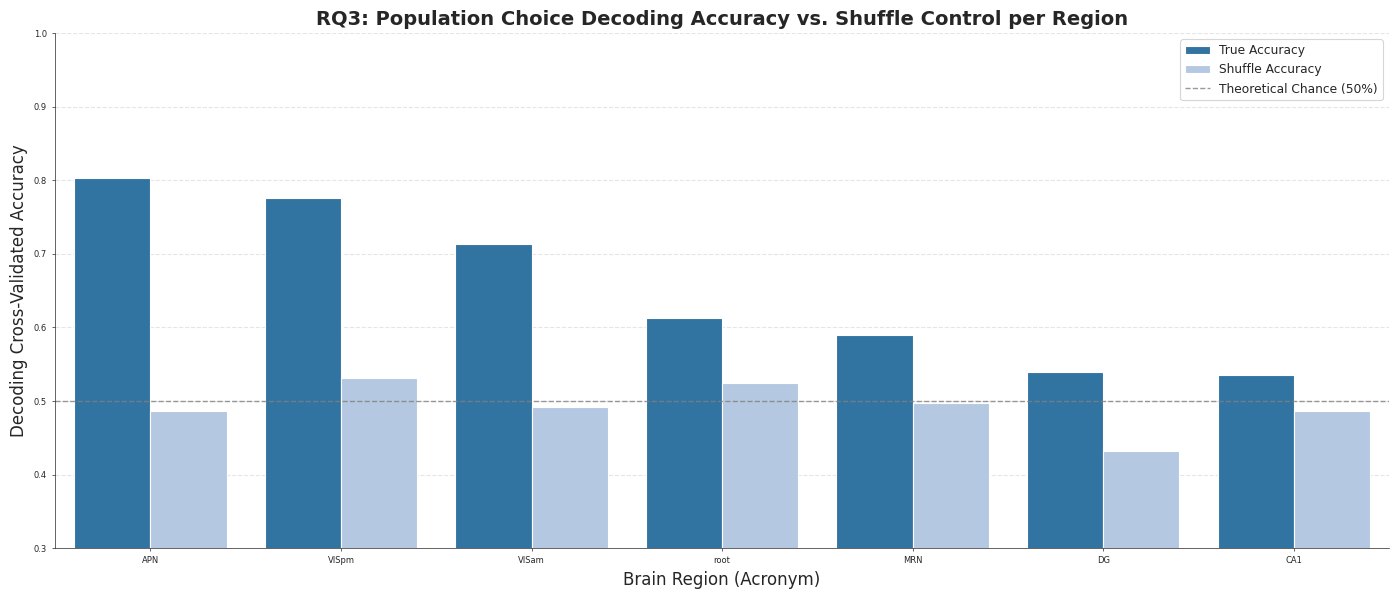

In [ ]:
plot_data = pd.melt(
    results_df,
    id_vars=['Region'],
    value_vars=['True Accuracy', 'Shuffle Accuracy'],
    var_name='Condition',
    value_name='Accuracy'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_data,
    x='Region',
    y='Accuracy',
    hue='Condition',
    palette=['#1f77b4', '#aec7e8']
)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.8, label='Theoretical Chance (50%)')
plt.title('RQ3: Population Choice Decoding Accuracy vs. Shuffle Control per Region', fontsize=14, fontweight='bold')
plt.xlabel('Brain Region (Acronym)', fontsize=12)
plt.ylabel('Decoding Cross-Validated Accuracy', fontsize=12)
plt.ylim(0.3, 1.0)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## RQ-Bonus

In [ ]:
download_data('stimOn')
meta_stim = load_metadata('stimOn')

pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"
psth_stim, df_stim, trials_stim = get_psth_for_insertion(pid, meta_stim)

block_prior = trials_stim['probabilityLeft'].values

valid_block_idx = (block_prior == 0.8) | (block_prior == 0.2)

X_all_trials = psth_stim[valid_block_idx, :, :]
y_block = np.where(block_prior[valid_block_idx] == 0.8, 1, 0)

In [ ]:
stim_times = meta_stim['times']
pre_stim_idx = (stim_times >= -0.4) & (stim_times <= -0.05)

X_expectation = np.mean(X_all_trials[:, :, pre_stim_idx], axis=2)

In [ ]:
unique_regions = df_stim['acronym'].unique()
block_decoding_results = []

MIN_NEURONS = 5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for region in unique_regions:
    region_neuron_indices = np.where(df_stim['acronym'].values == region)[0]

    if len(region_neuron_indices) < MIN_NEURONS:
        continue

    X_region = X_expectation[:, region_neuron_indices]

    true_accuracies = []
    shuffled_accuracies = []

    y_shuffled = np.random.permutation(y_block)

    for train_idx, test_idx in cv.split(X_region, y_block):
        X_train, X_test = X_region[train_idx], X_region[test_idx]
        y_train, y_test = y_block[train_idx], y_block[test_idx]
        y_train_shuff, y_test_shuff = y_shuffled[train_idx], y_shuffled[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        model = LogisticRegression(C=0.5, max_iter=1000, solver='liblinear')

        model.fit(X_train_scaled, y_train)
        true_accuracies.append(accuracy_score(y_test, model.predict(X_test_scaled)))

        model.fit(X_train_scaled, y_train_shuff)
        shuffled_accuracies.append(accuracy_score(y_test_shuff, model.predict(X_test_scaled)))

    block_decoding_results.append({
        'Region': region,
        'Neurons Count': len(region_neuron_indices),
        'True Accuracy': np.mean(true_accuracies),
        'Shuffle Accuracy': np.mean(shuffled_accuracies)
    })

block_results_df = pd.DataFrame(block_decoding_results)
block_results_df = block_results_df.sort_values(by='True Accuracy', ascending=False)

print("\n--- Pre-Stimulus Block Prior Decoding Leaderboard ---")
print(block_results_df.to_string(index=False))


--- Pre-Stimulus Block Prior Decoding Leaderboard ---
Region  Neurons Count  True Accuracy  Shuffle Accuracy
   APN             30       0.599304          0.549082
 VISpm             43       0.581614          0.496203
 VISam             17       0.574494          0.596899
   CA1             13       0.574114          0.526297
    DG              5       0.546614          0.491171
   MRN              6       0.539146          0.551456
  root              8       0.534051          0.516519


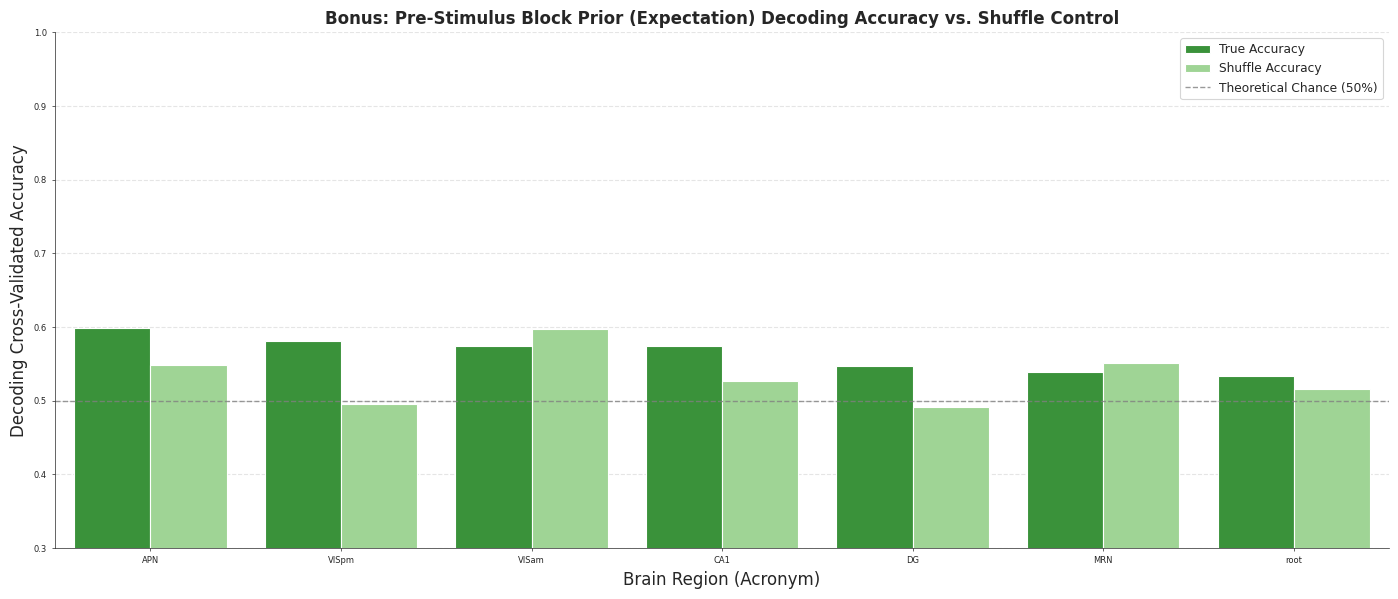

In [ ]:
plot_data_bonus = pd.melt(
    block_results_df,
    id_vars=['Region'],
    value_vars=['True Accuracy', 'Shuffle Accuracy'],
    var_name='Condition',
    value_name='Accuracy'
)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_data_bonus,
    x='Region',
    y='Accuracy',
    hue='Condition',
    palette=['#2ca02c', '#98df8a']
)

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.8, label='Theoretical Chance (50%)')
plt.title('Bonus: Pre-Stimulus Block Prior (Expectation) Decoding Accuracy vs. Shuffle Control', fontsize=12, fontweight='bold')
plt.xlabel('Brain Region (Acronym)', fontsize=12)
plt.ylabel('Decoding Cross-Validated Accuracy', fontsize=12)
plt.ylim(0.3, 1.0)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# More

## RQ1 — Identify stimulus-responsive units


In [ ]:
from scipy.stats import wilcoxon
import statsmodels.stats.multitest as smm


In [ ]:
# 1. LOAD DATA & METADATA (Aligned to Stimulus Onset)
download_data('stimOn')
meta = load_metadata('stimOn')


In [ ]:
# Select a representative session / probe insertion id (pid)
pid = "0393f34c-a2bd-4c01-99c9-f6b4ec6e786d"


In [ ]:
# Retrieve the PSTH matrices, cluster DataFrame, and trial metadata
psth, df, trials = get_psth_for_insertion(pid, meta)
# psth shape is (n_trials, n_clusters, n_time_bins)


In [ ]:
# 2. ISOLATE TIME WINDOWS & CALCULATE METRICS PER TRIAL
# Identify index masks for the pre-stimulus (-200ms to 0ms) and post-stimulus (0ms to 200ms) bins
pre_window_idx = (meta['times'] >= -0.2) & (meta['times'] < 0.0)
post_window_idx = (meta['times'] >= 0.0) & (meta['times'] <= 0.2)

n_trials, n_clusters, _ = psth.shape
p_values = []
modulation_indices = []


In [ ]:
n_trials, n_clusters, _ = psth.shape

p_values = []
modulation_indices = []
mean_pre_values = []
mean_post_values = []
# Loop over every unit (cluster) to test individual trial dynamics
for c in range(n_clusters):
    # Extract firing rates across all trials for the current cluster
    trial_pre_rates = np.mean(psth[:, c, pre_window_idx], axis=1)
    trial_post_rates = np.mean(psth[:, c, post_window_idx], axis=1)

    # Calculate the average Modulation Index (MI) for this cluster across the session
    mean_pre = np.mean(trial_pre_rates)
    mean_post = np.mean(trial_post_rates)

    # Append mean_pre and mean_post to their respective lists
    mean_pre_values.append(mean_pre)
    mean_post_values.append(mean_post)

    if (mean_pre + mean_post) == 0:
        mi = 0.0
    else:
        mi = abs(mean_post - mean_pre) / (mean_post + mean_pre)
    modulation_indices.append(mi)

    # Perform a paired Wilcoxon signed-rank test across trials to see if changes are stable
    # If a neuron's firing rate is completely flat (all zeros), catch the variance error
    if np.array_equal(trial_pre_rates, trial_post_rates):
        p_values.append(1.0)
    else:
        stat, p_val = wilcoxon(trial_post_rates, trial_pre_rates)
        p_values.append(p_val)

In [ ]:
# The content of this cell has been merged into cell b8ZcDA-oZ4Ec for correct execution of the loop.

In [ ]:
# Add computed arrays back into our main structural cluster DataFrame
#df['p_value'] = p_values
#df['modulation_index'] = modulation_indices
df['psth_index'] = np.arange(n_clusters)
df['mean_pre'] = mean_pre_values
df['mean_post'] = mean_post_values
df['response_difference'] = df['mean_post'] - df['mean_pre']
df['p_value'] = p_values
df['modulation_index'] = modulation_indices

In [ ]:
# 3. MULTIPLE-COMPARISON CORRECTION (FDR)
# Because we are testing hundreds of neurons simultaneously, we must correct for false positives
reject, pvals_corrected, _, _ = smm.multipletests(df['p_value'].values, alpha=0.05, method='fdr_bh')
df['q_value'] = pvals_corrected
df['is_responsive'] = reject

In [ ]:
# 4. GROUP BY ANATOMICAL REGION & RANK
# Calculate total recorded neurons vs statistically responsive ones per neighborhood
region_stats = df.groupby('acronym').agg(
    total_units=('cluster_id', 'count'),
    responsive_units=('is_responsive', 'sum')
).reset_index()


In [ ]:
# Calculate the metric: percent responsive units per region
region_stats['percent_responsive'] = (region_stats['responsive_units'] / region_stats['total_units']) * 100


In [ ]:
# Sort the regional leaderboard from most responsive to least responsive
region_stats = region_stats.sort_values(by='percent_responsive', ascending=False)

print("\n--- Regional Responsiveness Leaderboard ---")
print(region_stats[['acronym', 'total_units', 'responsive_units', 'percent_responsive']].to_string(index=False))



--- Regional Responsiveness Leaderboard ---
acronym  total_units  responsive_units  percent_responsive
    MRN            6                 6          100.000000
    CA1           13                 9           69.230769
  VISam           17                11           64.705882
    APN           30                19           63.333333
   root            8                 5           62.500000
     DG            5                 3           60.000000
  VISpm           43                25           58.139535


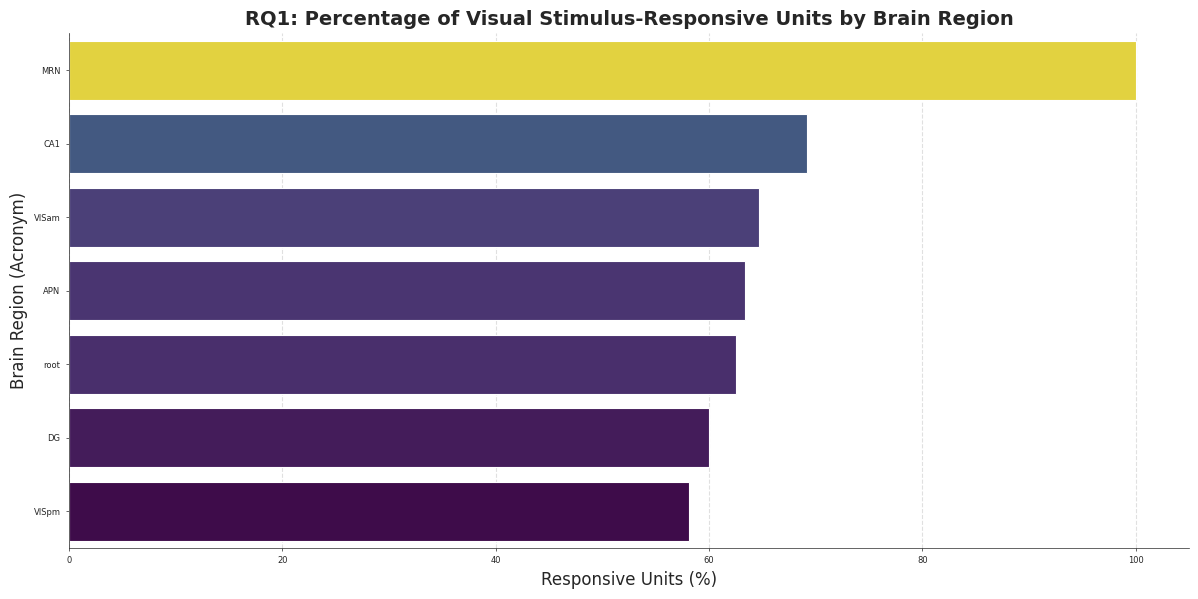

In [ ]:
# 5. VISUALIZE RANKED LEADERBOARD
plt.figure(figsize=(12, 6))
sns.barplot(
    data=region_stats,
    x='percent_responsive',
    y='acronym',
    palette='viridis',
    hue='percent_responsive',
    legend=False
)

plt.title('RQ1: Percentage of Visual Stimulus-Responsive Units by Brain Region', fontsize=14, fontweight='bold')
plt.xlabel('Responsive Units (%)', fontsize=12)
plt.ylabel('Brain Region (Acronym)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# Save RQ1 results
df.to_csv(
    "RQ1_single_insertion_results.csv",
    index=False
)

print(df.columns)
print("Total units:", len(df))
print("Responsive units:", df["is_responsive"].sum())

df.head()

Index(['acronym', 'pid', 'uuids', 'cluster_id', 'psth_index', 'mean_pre',
       'mean_post', 'response_difference', 'p_value', 'modulation_index',
       'q_value', 'is_responsive'],
      dtype='object')
Total units: 122
Responsive units: 78


,acronym,pid,uuids,cluster_id,psth_index,mean_pre,mean_post,response_difference,p_value,modulation_index,q_value,is_responsive
7948,MRN,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,564682e3-4453-4424-8183-7206a3357bd8,13,0,28.326134,47.721382,19.395248,1.048397e-46,0.255041,1.279045e-44,True
7949,MRN,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,deb16e16-1251-4694-b238-17b1dbf3e99e,30,1,0.259179,0.431965,0.172786,1.981815e-02,0.250000,3.181334e-02,True
7950,MRN,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,ba9795f3-ba72-481b-8671-5e8544061da2,32,2,55.680346,57.613391,1.933045,4.651560e-03,0.017062,8.598338e-03,True
7951,MRN,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,11a1b652-e8a7-4dae-bb2f-dc703aeaca13,37,3,0.118790,1.414687,1.295896,9.853108e-20,0.845070,8.013861e-19,True
7952,MRN,0393f34c-a2bd-4c01-99c9-f6b4ec6e786d,b2407aa4-9029-4928-8aef-7bf46ab6482e,39,4,48.261339,42.278618,-5.982721,5.867960e-27,0.066078,5.965759e-26,True


## RQ2 — Response latency for stimulus-responsive units


In [ ]:
# Keep only responsive neurons from RQ1
responsive_df = df[df["is_responsive"] == True].copy()

print("Total units:", len(df))
print("Responsive units:", len(responsive_df))

responsive_df[
    [
        "cluster_id",
        "acronym",
        "psth_index",
        "mean_pre",
        "mean_post",
        "response_difference",
        "q_value"
    ]
].head()

Total units: 122
Responsive units: 78


,cluster_id,acronym,psth_index,mean_pre,mean_post,response_difference,q_value
7948,13,MRN,0,28.326134,47.721382,19.395248,1.279045e-44
7949,30,MRN,1,0.259179,0.431965,0.172786,3.181334e-02
7950,32,MRN,2,55.680346,57.613391,1.933045,8.598338e-03
7951,37,MRN,3,0.118790,1.414687,1.295896,8.013861e-19
7952,39,MRN,4,48.261339,42.278618,-5.982721,5.965759e-26


In [ ]:
from scipy.ndimage import gaussian_filter1d

# Select the first responsive neuron
unit = responsive_df.iloc[0]

psth_idx = int(unit["psth_index"])

# Activity of this neuron:
# shape = trials × time bins
unit_trials = psth[:, psth_idx, :]

# Average across trials
mean_psth = np.mean(unit_trials, axis=0)

# Mild smoothing
smoothed_psth = gaussian_filter1d(mean_psth, sigma=1)

print("Region:", unit["acronym"])
print("PSTH index:", psth_idx)
print("Response difference:", unit["response_difference"])

Region: MRN
PSTH index: 0
Response difference: 19.395248380129587


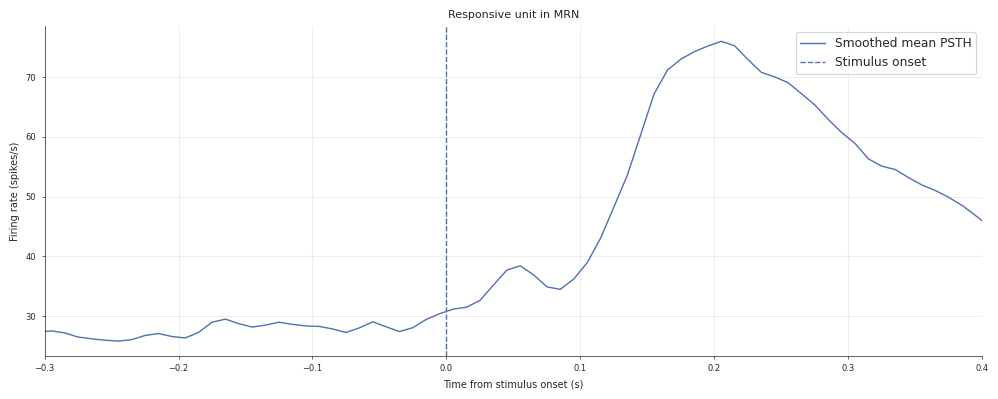

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(
    meta["times"],
    smoothed_psth,
    label="Smoothed mean PSTH"
)

plt.axvline(
    0,
    linestyle="--",
    label="Stimulus onset"
)

plt.xlim(-0.3, 0.4)
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Firing rate (spikes/s)")
plt.title(
    f'Responsive unit in {unit["acronym"]}'
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
baseline_mask = (
    (meta["times"] >= -0.30) &
    (meta["times"] < -0.05)
)

search_mask = (
    (meta["times"] >= 0.0) &
    (meta["times"] <= 0.30)
)

baseline_mean = np.mean(smoothed_psth[baseline_mask])
baseline_std = np.std(smoothed_psth[baseline_mask])

upper_threshold = baseline_mean + 2 * baseline_std
lower_threshold = baseline_mean - 2 * baseline_std

print("Baseline mean:", baseline_mean)
print("Baseline SD:", baseline_std)
print("Upper threshold:", upper_threshold)
print("Lower threshold:", lower_threshold)

Baseline mean: 27.60315327101991
Baseline SD: 1.087065256572961
Upper threshold: 29.77728378416583
Lower threshold: 25.429022757873987


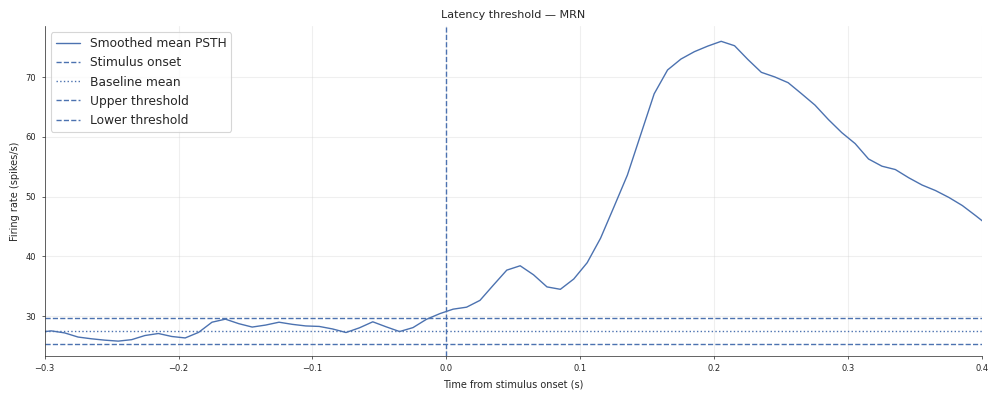

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(
    meta["times"],
    smoothed_psth,
    label="Smoothed mean PSTH"
)

plt.axvline(
    0,
    linestyle="--",
    label="Stimulus onset"
)

plt.axhline(
    baseline_mean,
    linestyle=":",
    label="Baseline mean"
)

plt.axhline(
    upper_threshold,
    linestyle="--",
    label="Upper threshold"
)

plt.axhline(
    lower_threshold,
    linestyle="--",
    label="Lower threshold"
)

plt.xlim(-0.3, 0.4)
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Firing rate (spikes/s)")
plt.title(
    f'Latency threshold — {unit["acronym"]}'
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Detect latency for the neuron plotted!


In [ ]:
# Extract the post-stimulus search period
search_times = np.asarray(meta["times"])[search_mask]
search_activity = smoothed_psth[search_mask]

# Decide whether this neuron increased or decreased its firing
response_difference = unit["response_difference"]

if response_difference >= 0:
    crossing_condition = search_activity > upper_threshold
    response_direction = "increase"
else:
    crossing_condition = search_activity < lower_threshold
    response_direction = "decrease"

print("Response direction:", response_direction)
print("Threshold crossings:", crossing_condition)

Response direction: increase
Threshold crossings: [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]


In [ ]:
def first_sustained_crossing(condition, n_consecutive=3):
    """
    Return the index of the first run of consecutive True values.

    Parameters
    ----------
    condition : array-like of bool
        Whether the signal crosses the threshold in each time bin.
    n_consecutive : int
        Required number of consecutive threshold-crossing bins.

    Returns
    -------
    int or None
        Index of the first sustained crossing, or None if absent.
    """
    condition = np.asarray(condition, dtype=bool)

    for i in range(len(condition) - n_consecutive + 1):
        if np.all(condition[i:i + n_consecutive]):
            return i

    return None

In [ ]:
crossing_idx = first_sustained_crossing(
    crossing_condition,
    n_consecutive=3
)

if crossing_idx is None:
    latency = np.nan
    print("No reliable latency detected.")
else:
    latency = search_times[crossing_idx]
    print(f"Detected latency: {latency * 1000:.0f} ms")

Detected latency: 5 ms


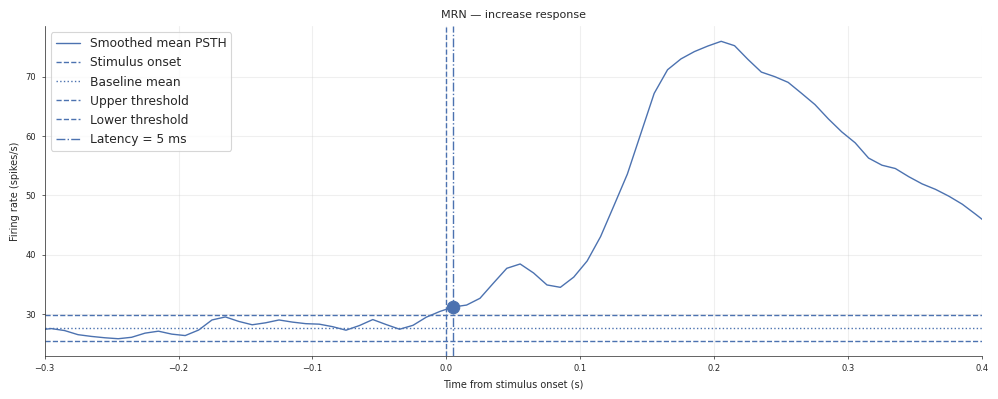

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(
    meta["times"],
    smoothed_psth,
    label="Smoothed mean PSTH"
)

plt.axvline(
    0,
    linestyle="--",
    label="Stimulus onset"
)

plt.axhline(
    baseline_mean,
    linestyle=":",
    label="Baseline mean"
)

plt.axhline(
    upper_threshold,
    linestyle="--",
    label="Upper threshold"
)

plt.axhline(
    lower_threshold,
    linestyle="--",
    label="Lower threshold"
)

if np.isfinite(latency):
    plt.axvline(
        latency,
        linestyle="-.",
        label=f"Latency = {latency * 1000:.0f} ms"
    )

    latency_bin = np.argmin(
        np.abs(np.asarray(meta["times"]) - latency)
    )

    plt.scatter(
        latency,
        smoothed_psth[latency_bin],
        s=80,
        zorder=5
    )

plt.xlim(-0.3, 0.4)
plt.xlabel("Time from stimulus onset (s)")
plt.ylabel("Firing rate (spikes/s)")
plt.title(
    f'{unit["acronym"]} — {response_direction} response'
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
def estimate_response_latency(
    psth,
    psth_index,
    times,
    response_difference,
    baseline_window=(-0.30, -0.05),
    search_window=(0.0, 0.30),
    threshold_sd=2.0,
    n_consecutive=3,
    smoothing_sigma=1
):
    """
    Estimate stimulus-response onset latency for one neuron.

    Parameters
    ----------
    psth : ndarray
        PSTH array with shape trials × neurons × time bins.
    psth_index : int
        Index of the neuron in the PSTH array.
    times : ndarray
        Time values relative to stimulus onset.
    response_difference : float
        Mean post-stimulus rate minus mean pre-stimulus rate.
    baseline_window : tuple
        Baseline interval in seconds.
    search_window : tuple
        Post-stimulus interval in which latency is detected.
    threshold_sd : float
        Number of baseline standard deviations required.
    n_consecutive : int
        Number of consecutive bins required.
    smoothing_sigma : float
        Gaussian smoothing parameter.

    Returns
    -------
    dict
        Latency and quality-control measurements.
    """

    times = np.asarray(times)

    if psth_index < 0 or psth_index >= psth.shape[1]:
        return {
            "latency_s": np.nan,
            "latency_ms": np.nan,
            "response_direction": None,
            "baseline_mean": np.nan,
            "baseline_std": np.nan,
            "threshold": np.nan
        }

    # Trials × time bins
    unit_trials = psth[:, int(psth_index), :]

    # Average across trials
    mean_psth = np.nanmean(unit_trials, axis=0)

    # Mild temporal smoothing
    smoothed_psth = gaussian_filter1d(
        mean_psth,
        sigma=smoothing_sigma
    )

    baseline_mask = (
        (times >= baseline_window[0]) &
        (times < baseline_window[1])
    )

    search_mask = (
        (times >= search_window[0]) &
        (times <= search_window[1])
    )

    if not np.any(baseline_mask) or not np.any(search_mask):
        return {
            "latency_s": np.nan,
            "latency_ms": np.nan,
            "response_direction": None,
            "baseline_mean": np.nan,
            "baseline_std": np.nan,
            "threshold": np.nan
        }

    baseline_values = smoothed_psth[baseline_mask]

    baseline_mean = np.nanmean(baseline_values)
    baseline_std = np.nanstd(baseline_values)

    search_activity = smoothed_psth[search_mask]
    search_times = times[search_mask]

    if response_difference >= 0:
        response_direction = "increase"
        threshold = baseline_mean + threshold_sd * baseline_std
        crossing_condition = search_activity > threshold
    else:
        response_direction = "decrease"
        threshold = baseline_mean - threshold_sd * baseline_std
        crossing_condition = search_activity < threshold

    crossing_idx = first_sustained_crossing(
        crossing_condition,
        n_consecutive=n_consecutive
    )

    if crossing_idx is None:
        latency_s = np.nan
    else:
        latency_s = search_times[crossing_idx]

    return {
        "latency_s": latency_s,
        "latency_ms": latency_s * 1000
        if np.isfinite(latency_s) else np.nan,
        "response_direction": response_direction,
        "baseline_mean": baseline_mean,
        "baseline_std": baseline_std,
        "threshold": threshold
    }

In [ ]:
test_result = estimate_response_latency(
    psth=psth,
    psth_index=int(unit["psth_index"]),
    times=meta["times"],
    response_difference=unit["response_difference"]
)

test_result

{'latency_s': np.float64(0.005),
 'latency_ms': np.float64(5.0),
 'response_direction': 'increase',
 'baseline_mean': np.float64(27.60315327101991),
 'baseline_std': np.float64(1.087065256572961),
 'threshold': np.float64(29.77728378416583)}

Apply the method to every responsive neuron in this insertion

In [ ]:
latency_results = []

for _, responsive_unit in responsive_df.iterrows():

    result = estimate_response_latency(
        psth=psth,
        psth_index=int(responsive_unit["psth_index"]),
        times=meta["times"],
        response_difference=responsive_unit["response_difference"]
    )

    latency_results.append(result)

In [ ]:
latency_df = pd.DataFrame(latency_results)

responsive_df = responsive_df.reset_index(drop=True)

responsive_df = pd.concat(
    [
        responsive_df,
        latency_df
    ],
    axis=1
)

In [ ]:
responsive_df[
    [
        "cluster_id",
        "acronym",
        "response_direction",
        "response_difference",
        "latency_ms"
    ]
].head(20)

,cluster_id,acronym,response_direction,response_difference,latency_ms
0,13,MRN,increase,19.395248,5.0
1,30,MRN,increase,0.172786,165.0
2,32,MRN,increase,1.933045,115.0
3,37,MRN,increase,1.295896,65.0
4,39,MRN,decrease,-5.982721,45.0
5,41,MRN,decrease,-2.559395,115.0
6,51,APN,increase,1.187905,155.0
7,56,APN,increase,1.155508,45.0
8,57,APN,increase,6.015119,115.0
9,69,APN,increase,2.429806,5.0


How many valid latencies were found

In [ ]:
print("Responsive units:", len(responsive_df))

print(
    "Units with valid latency:",
    responsive_df["latency_ms"].notna().sum()
)

print(
    "Percentage with valid latency:",
    100 * responsive_df["latency_ms"].notna().mean()
)

Responsive units: 78
Units with valid latency: 77
Percentage with valid latency: 98.71794871794873


In [ ]:
responsive_df["latency_ms"].describe()

,latency_ms
count,77.000000
mean,74.480519
std,46.506822
min,5.000000
25%,45.000000
50%,75.000000
75%,115.000000
max,165.000000


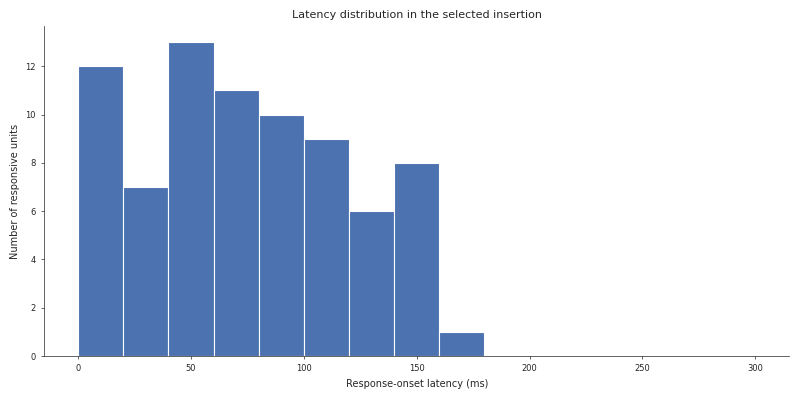

In [ ]:
valid_latencies = responsive_df[
    responsive_df["latency_ms"].notna()
]

plt.figure(figsize=(8, 4))

plt.hist(
    valid_latencies["latency_ms"],
    bins=np.arange(0, 320, 20)
)

plt.xlabel("Response-onset latency (ms)")
plt.ylabel("Number of responsive units")
plt.title("Latency distribution in the selected insertion")
plt.tight_layout()
plt.show()

In [ ]:
responsive_df.to_csv(
    "RQ2_single_insertion_latencies.csv",
    index=False
)

## RQ3 — Decoding left versus right choice from population activity

In [ ]:
# Download neural activity aligned to first movement
download_data("firstMove")

# Load metadata
meta_move = load_metadata("firstMove")

print("Time bins:", meta_move.times.shape)
print("Time range:", meta_move.times[0], "to", meta_move.times[-1])
print("Clusters:", meta_move.clusters.shape)
print("Trials:", meta_move.trials.shape)

Time bins: (150,)
Time range: -0.495 to 0.995
Clusters: (75708, 11)
Trials: (196503, 9)


In [ ]:
test_pid = "8ca1a850-26ef-42be-8b28-c2e2d12f06d6"

psth_move, clusters_move, trials_move = get_psth_for_insertion(
    test_pid,
    meta_move
)

print("PSTH shape:", psth_move.shape)
print("Clusters:", clusters_move.shape)
print("Trials:", trials_move.shape)

PSTH shape: (569, 172, 150)
Clusters: (172, 5)
Trials: (569, 9)


In [ ]:
print(trials_move["choice"].value_counts(dropna=False))

choice
 1.0    388
-1.0    181
Name: count, dtype: int64


Inspect the regions in this insertion

WE ask for decoding per brain region, not from all neurons mixed together.

In [ ]:
region_counts = (
    clusters_move["acronym"]
    .value_counts()
    .sort_values(ascending=False)
)

print(region_counts.head(20))

acronym
PO        86
LD        47
SSp-tr    18
CA1       10
CA3        8
CA2        2
root       1
Name: count, dtype: int64


In [ ]:
valid_region_counts = region_counts[
    ~region_counts.index.isin(["root", "void"])
]

test_region = valid_region_counts.index[0]

print("Test region:", test_region)
print("Units in region:", valid_region_counts.iloc[0])

Test region: PO
Units in region: 86


This is only for testing the decoder. Later, we will repeat the analysis across regions and insertions.

Define the pre-movement window

The starter notebook uses the final 100 ms before movement:

−100 ms<t<0 ms


In [ ]:
pre_movement_mask = (
    (meta_move.times >= -0.10) &
    (meta_move.times < 0.0)
)

print("Selected time bins:", pre_movement_mask.sum())
print(
    "Window:",
    meta_move.times[pre_movement_mask][0],
    "to",
    meta_move.times[pre_movement_mask][-1]
)

Selected time bins: 10
Window: -0.095 to -0.005


In [ ]:
region_unit_indices = (
    clusters_move.loc[
        clusters_move["acronym"] == test_region,
        "psth_index"
    ]
    .astype(int)
    .to_numpy()
)

print("PSTH indices:", region_unit_indices)

PSTH indices: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81 160 161 162 163]


In [ ]:
# Shape: trials × units × selected time bins
region_activity = psth_move[
    :,
    region_unit_indices,
    :
][:, :, pre_movement_mask]

# Average firing rate in the pre-movement window
# Final shape: trials × units
X = np.nanmean(region_activity, axis=2)

# Left/right choice label for every trial
y = trials_move["choice"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 86)
y shape: (569,)


Each row of X is one trial. Each column is one neuron.

The decoder learns:

population activity⟶left or right texte en gras
```





Remove invalid trials and uninformative units

In [ ]:
# Keep only valid binary choices
valid_trials = (
    np.isin(y, [-1, 1]) &
    np.all(np.isfinite(X), axis=1)
)

X = X[valid_trials]
y = y[valid_trials]

# Remove neurons with no variance across trials
variable_units = np.nanvar(X, axis=0) > 0

X = X[:, variable_units]

print("Valid trials:", X.shape[0])
print("Usable units:", X.shape[1])
print("Choices:", np.unique(y, return_counts=True))

Valid trials: 569
Usable units: 86
Choices: (array([-1.,  1.]), array([181, 388]))


If X.shape[1] is zero, choose another region with more usable neurons.

**Decoding**

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    permutation_test_score
)

In [ ]:
#Define the cross-validation procedure
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [ ]:
decoder = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=0
    )
)

We will use balanced accuracy because the mouse may make one choice more frequently than the other.

With balanced accuracy:

**chance level=0.5**


even when the number of left and right trials is unequal.

In [ ]:
#Calculate cross-validated decoding accuracy

In [ ]:
cv_scores = cross_val_score(
    decoder,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Fold accuracies:", np.round(cv_scores, 3))
print(
    "Mean balanced accuracy:",
    np.round(cv_scores.mean(), 3)
)
print(
    "Accuracy SD:",
    np.round(cv_scores.std(), 3)
)

Fold accuracies: [0.848 0.768 0.869 0.76  0.837]
Mean balanced accuracy: 0.816
Accuracy SD: 0.044


Compare against shuffled labels

Using a small number of permutations for the first test:

In [ ]:
observed_score, shuffled_scores, permutation_p = (
    permutation_test_score(
        decoder,
        X,
        y,
        scoring="balanced_accuracy",
        cv=cv,
        n_permutations=50,
        random_state=0,
        n_jobs=-1
    )
)

print(
    "Observed accuracy:",
    np.round(observed_score, 3)
)

print(
    "Mean shuffled accuracy:",
    np.round(shuffled_scores.mean(), 3)
)

print(
    "Accuracy above shuffle:",
    np.round(
        observed_score - shuffled_scores.mean(),
        3
    )
)

print(
    "Permutation p-value:",
    np.round(permutation_p, 4)
)

Observed accuracy: 0.816
Mean shuffled accuracy: 0.5
Accuracy above shuffle: 0.316
Permutation p-value: 0.0196


In [ ]:
n_permutations=200

In [ ]:
#Plotting observed accuracy against the shuffled distribution

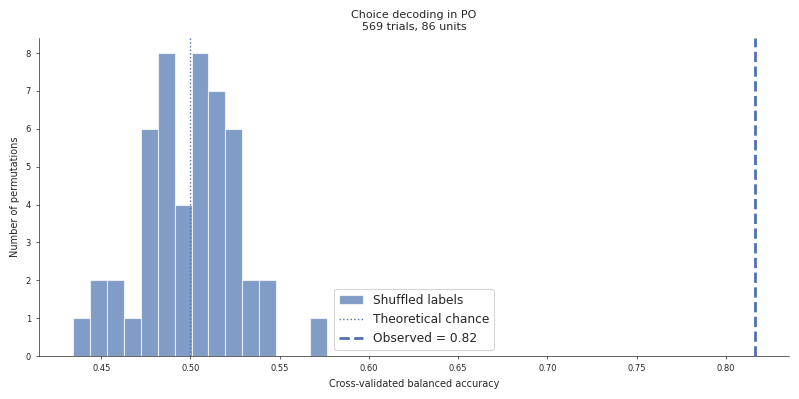

In [ ]:
plt.figure(figsize=(8, 4))

plt.hist(
    shuffled_scores,
    bins=15,
    alpha=0.7,
    label="Shuffled labels"
)

plt.axvline(
    0.5,
    linestyle=":",
    label="Theoretical chance"
)

plt.axvline(
    observed_score,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {observed_score:.2f}"
)

plt.xlabel("Cross-validated balanced accuracy")
plt.ylabel("Number of permutations")
plt.title(
    f"Choice decoding in {test_region}\n"
    f"{len(y)} trials, {X.shape[1]} units"
)

plt.legend()
plt.tight_layout()
plt.show()